# Optimising a Logistic Regression Classifier

In this notebook, we demonstrate how to **tune hyperparameters** in a Logistic Regression model to improve performance.

## Step 1: Load Breast Cancer Data

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31
)

# Normalize (Standardize) features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 2: Define a Function to Train and Evaluate

This function will:
- Train the model
- Return training and test accuracy

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

def train_and_evaluate(max_iter=5000, C=1, penalty='l2', solver='liblinear'):
    model = LogisticRegression(max_iter=max_iter, C=C, penalty=penalty, solver=solver)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    return train_acc, test_acc

## Regularization in Logistic Regression

In logistic regression, regularization is used to prevent overfitting by penalizing large coefficients.

### 🔹 L2 Regularization (Ridge)

Minimizes the following loss:

$$
\text{Loss} = \text{Log Loss} + \lambda \cdot \frac{1}{2} \sum_{j=1}^{p} w_j^2
$$

- $ \lambda  $ controls regularization strength (in scikit-learn: $ \lambda = \frac{1}{C} $.
- Shrinks coefficients smoothly towards zero, but rarely makes them exactly zero.
- Good for situations where all features may contribute a little.

---

### 🔹 L1 Regularization (Lasso)

Minimizes the following loss:

$$
\text{Loss} = \text{Log Loss} + \lambda \cdot \sum_{j=1}^{p} |w_j|
$$

- Encourages **sparse solutions** (some coefficients exactly zero).
- Useful for feature selection (automatic removal of irrelevant features).
- Can be harder to optimize due to the absolute value term.


## Step 3: Explore Effect of C (Inverse of Regularization Strength)

Controls the amount of regularization.
Effect:

Smaller C → Stronger regularization → Prevents overfitting but may underfit.

Larger C → Weaker regularization → Better fit but may overfit.

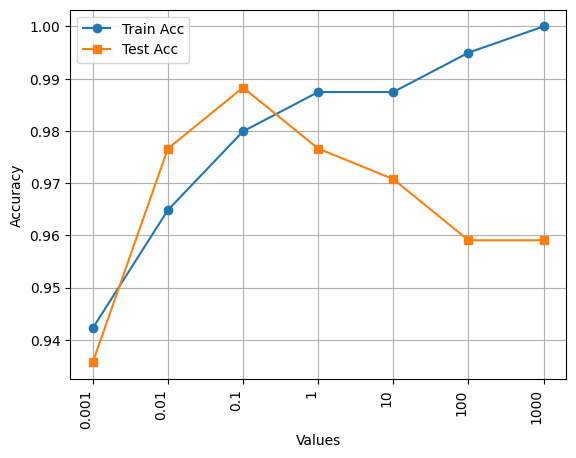

In [3]:
import matplotlib.pyplot as plt

values = [ 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000 ]
train_scores, test_scores = [], []

for v in values:
    tr, te = train_and_evaluate(C=v)
    train_scores.append(tr)
    test_scores.append(te)

labels = [str(s) for s in values]

plt.plot(labels, train_scores, marker='o', label='Train Acc')
plt.plot(labels, test_scores, marker='s', label='Test Acc')
plt.xlabel('Values')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(rotation=90, ha='right')
plt.show()

## Step 4: Explore Effect of `penalty` (L1, L2 Regularization)

| Penalty | Key Effect                  | When to Use                                              |
| ------- | --------------------------- | -------------------------------------------------------- |
| L1      | Sparsity, feature selection | You want simpler models or auto-feature selection        |
| L2      | Shrinkage, no sparsity      | You want to reduce overfitting without dropping features |


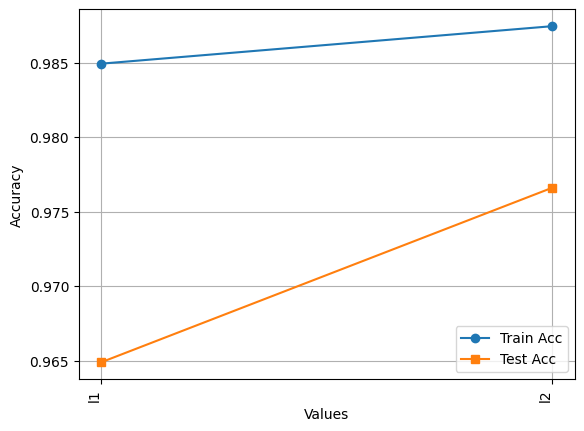

In [4]:
import matplotlib.pyplot as plt

values = [ 'l1', 'l2' ]
train_scores, test_scores = [], []

for v in values:
    tr, te = train_and_evaluate(penalty=v)
    train_scores.append(tr)
    test_scores.append(te)

labels = [str(s) for s in values]

plt.plot(labels, train_scores, marker='o', label='Train Acc')
plt.plot(labels, test_scores, marker='s', label='Test Acc')
plt.xlabel('Values')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(rotation=90, ha='right')
plt.show()

## Step 5: Explore Effect of `max_iter`

| **Scenario**                        | **Effect**                                                                                                                                                                                   |
| ----------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Too **low**                         | Model may **not converge** → You’ll see warnings like “STOP: TOTAL NO. OF F, G EVALUATIONS EXCEEDS LIMIT”. Model coefficients may be inaccurate or unstable.                                 |
| Sufficient (or slightly high)       | Model **converges properly**. No warnings. Coefficients stabilize at optimal values.                                                                                                         |
| Very **high** (but converges early) | No harm—most solvers **stop automatically** once convergence is reached (before hitting `max_iter`). However, unnecessarily large values can increase training time for very large datasets. |



C:\Users\moji1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\moji1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\moji1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\moji1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear 

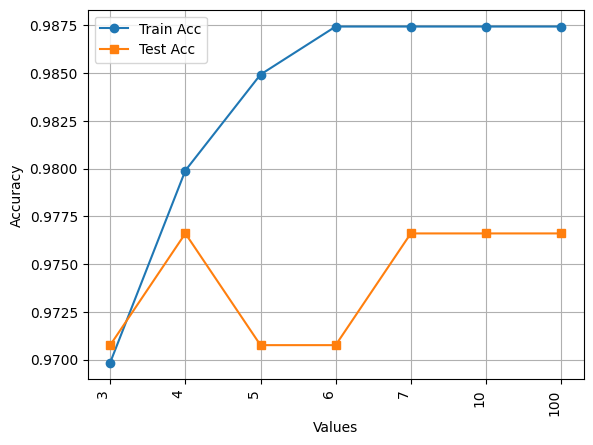

In [5]:
import matplotlib.pyplot as plt

values = [3, 4, 5, 6, 7, 10, 100 ]
train_scores, test_scores = [], []

for v in values:
    tr, te = train_and_evaluate(max_iter=v)
    train_scores.append(tr)
    test_scores.append(te)

labels = [str(s) for s in values]

plt.plot(labels, train_scores, marker='o', label='Train Acc')
plt.plot(labels, test_scores, marker='s', label='Test Acc')
plt.xlabel('Values')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(rotation=90, ha='right')
plt.show()

## Changing the Classification Threshold

Most classifiers output probabilities between 0 and 1.
By default, the threshold for classification is 0.5. This means:

- If predicted probability ≥ 0.5 → classify as **positive**
- Else → classify as **negative**

### Changing the Threshold:
- **Lower threshold** → more positives predicted → higher **recall**, more **false positives**
- **Higher threshold** → fewer positives predicted → higher **precision**, more **false negatives**

Choosing the right threshold depends on your application's goals.

We'll now visualize how the confusion matrix changes for **two different thresholds**.

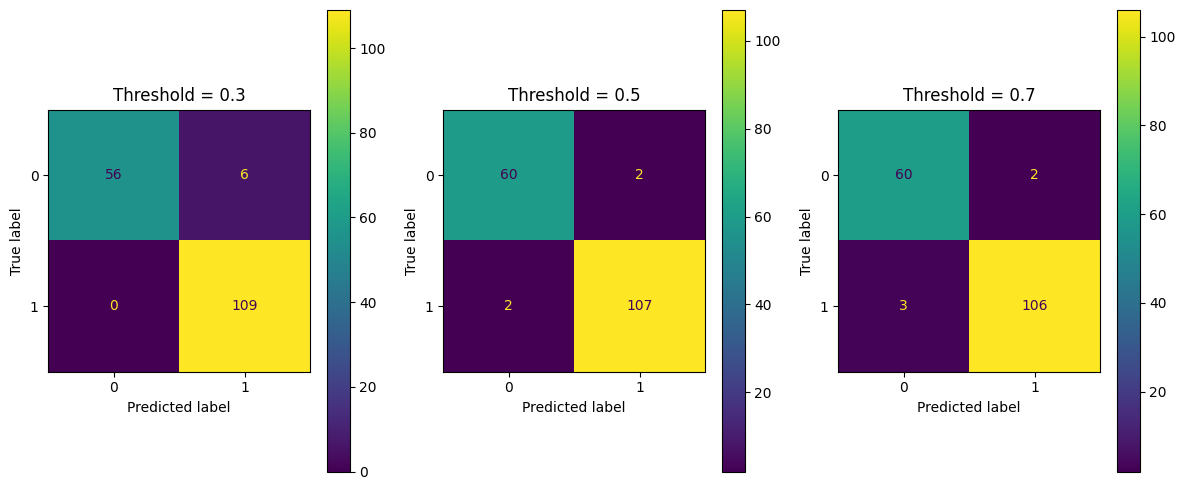

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

thresholds = [0.3, 0.5, 0.7]         # List of three thresholds to compare

# Retrain model
manual_model = LogisticRegression()
manual_model.fit(X_train, y_train)

# Predict probabilities
y_proba = manual_model.predict_proba(X_test)[:, 1]

# Plot side-by-side confusion matrices
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
for i, thresh in enumerate(thresholds):
    y_pred = (y_proba >= thresh).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axs[i])
    axs[i].set_title(f"Threshold = {thresh}")
plt.tight_layout()
plt.show()